# PREDICTION DE LA REUSSITE SCOLAIRE

## 1. IMPORT DES LIBRAIRIES

In [329]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
%matplotlib inline

## 2. CHARGEMENT DES DONNÉES

## Import des jeux de données bruts

In [330]:
raw_mat = pd.read_csv("./data/raw_mat.csv", sep=";")
raw_por = pd.read_csv("./data/raw_por.csv", sep=";")

## Fusion des jeux de données

In [331]:
raw_mat["source"] = "mat"
raw_por["source"] = "por"

merged = pd.concat([raw_mat, raw_por])
merged.to_csv("data/merged.csv", index=False)

## 3. EXPLORATION DES DONNÉES

## Colonnes

In [332]:
merged.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,source
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


### Données personnelles et familiales

- **school :** École fréquentée : GP (Gabriel Pereira) ou MS (Mousinho
da Silveira)
- **sex :** Sexe de l’élève : F (fille) ou M (garçon)
- **age :** Âge de l’élève (entre 15 et 22 ans)
- **address :** Type d’habitation : U (urbain) ou R (rural)
- **famsize :** Taille de la famille : LE3 (≤3) ou GT3 (>3) personnes
- **Pstatus :** Statut marital des parents : T (ensemble) ou A (séparés)
- **Medu :** Niveau d’éducation de la mère (0 à 4)
- **Fedu :** Niveau d’éducation du père (0 à 4)
- **Mjob :** Profession de la mère (enseignant, santé, services, à domicile, autre)
- **Fjob :** Profession du père (idem Mjob)
- **reason :** Raison du choix de l’école : proximité, réputation, etc.
- **guardian :** Tuteur/tutrice principal(e) : mère, père ou autre

### Contexte scolaire et extra-scolaire

- **traveltime :** Temps de trajet domicile-école (1= <15 min, 4= >1h)
- **studytime :** Temps d’étude hebdo (1= <2h, 4= >10h)
- **failures :** Nb d’échecs passés (1 si jamais redoublé, 4 si 3 redoublements ou plus)
- **schoolsup :** Soutien scolaire supplémentaire (yes/no)
- **famsup :** Soutien familial (yes/no)
- **paid :** Cours payants en maths (yes/no)
- **activities :** Activités extrascolaires (yes/no)
- **nursery :** Fréquentation d’une maternelle (yes/no)
- **higher :** Souhait de poursuivre des études supérieures (yes/no)
- **internet :** Accès à internet à la maison (yes/no)
- **romantic :** En couple ou non (yes/no)

### Vie quotidienne

- **famrel :** Qualité des relations familiales (1= très mauvaise, 5=
excellente)
- **freetime :** Temps libre après l’école (1 à 5)
- **goout :** Fréquence des sorties avec des amis (1 à 5)
- **Dalc :** Consommation d’alcool en semaine (1= très faible, 5=
très élevée)
- **Walc :** Consommation d’alcool le week-end (1 à 5)
- **health :** État de santé (1= très mauvais, 5= excellent)
- **absences :** Nombre d’absences scolaires

### Résultats scolaires

- **G1 :** Note au premier trimestre (0 à 20)
- **G2 :** Note au second trimestre (0 à 20)
- **G3 :** Note finale (0 à 20) — variable cible
- **source :** Source du fichier : mat ou por (mathématiques ou
portugais)

In [333]:
merged.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Données manquantes

Nous pouvons constater que toutes les colonnes sont entièrement remplies.

## 4. VISUALISATIONS

<Axes: >

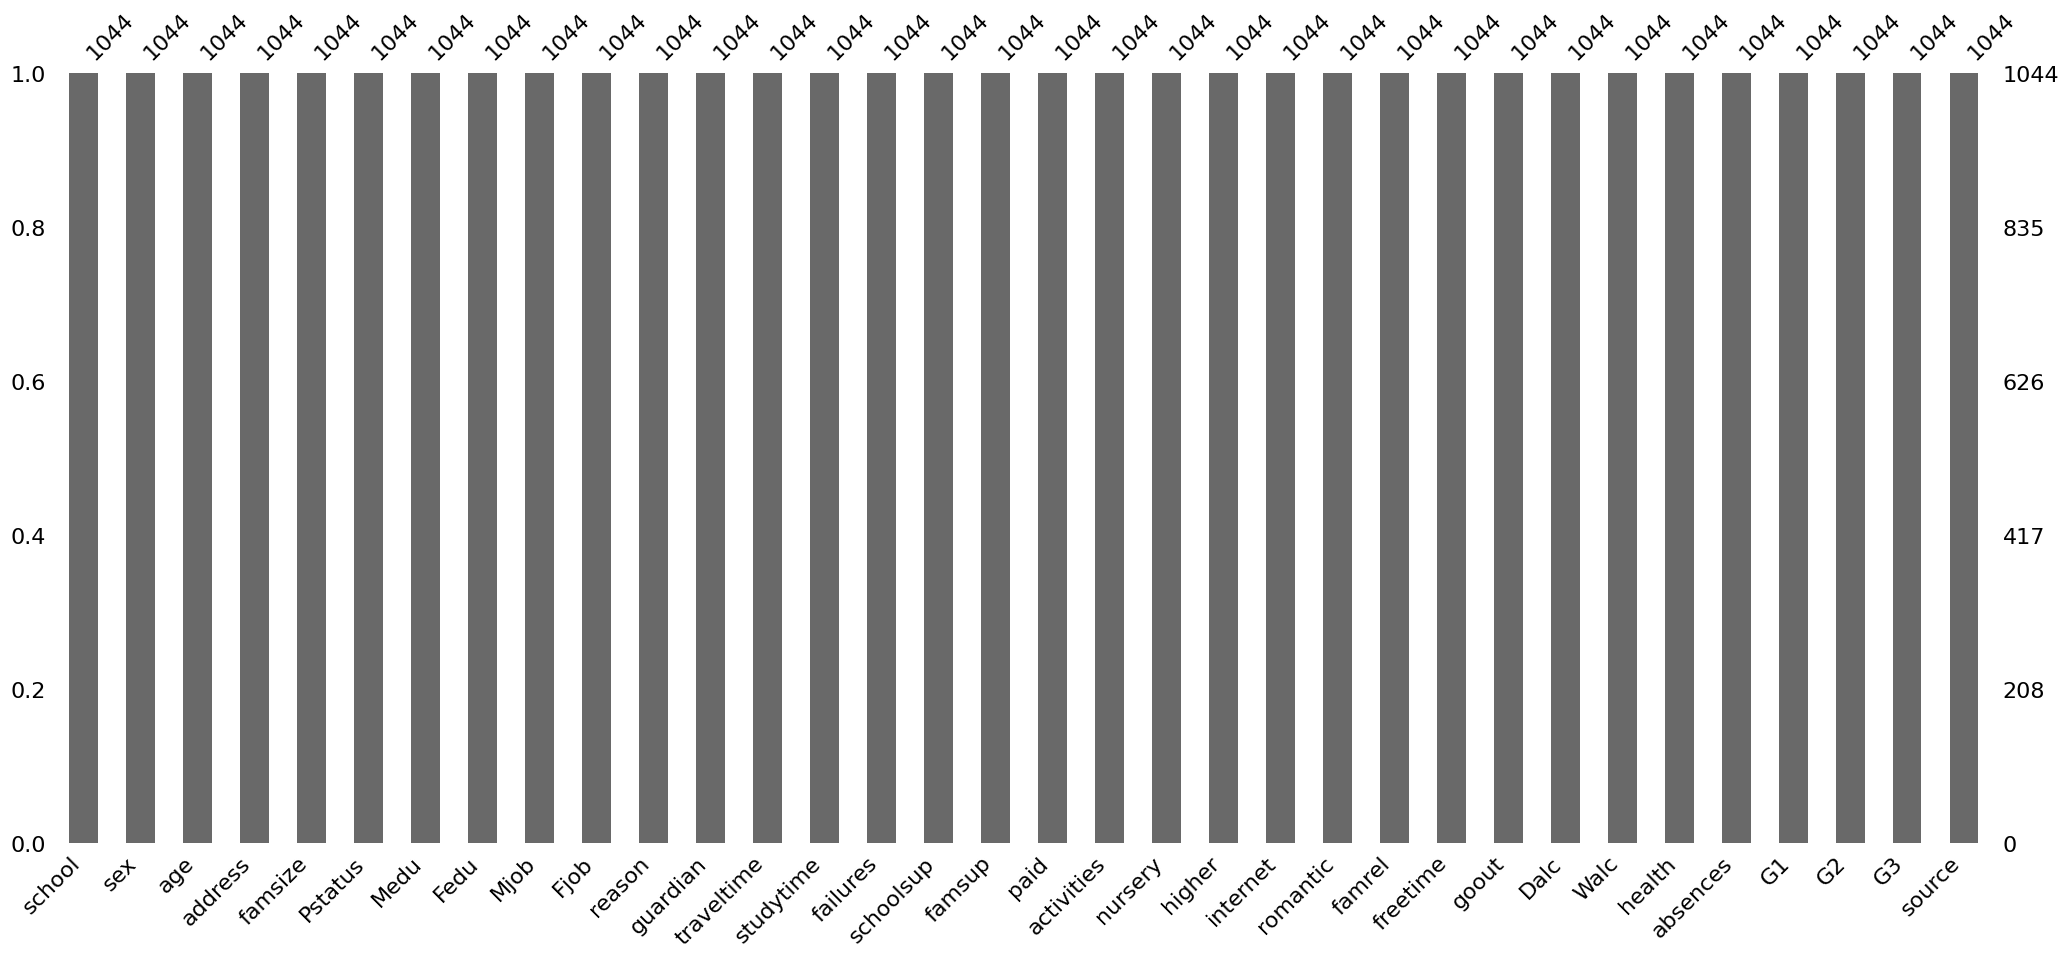

In [334]:
msno.bar(merged)

## Corrélations

<Axes: >

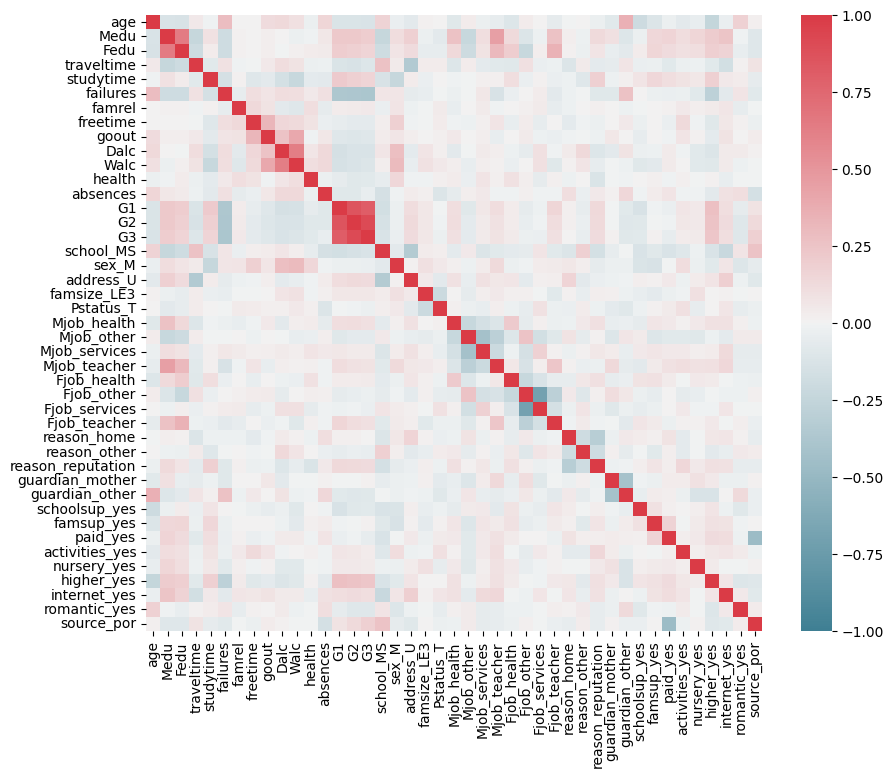

In [335]:
correlations = pd.get_dummies(merged, drop_first=True)

f, ax = plt.subplots(figsize=(10, 8))
corr = correlations.select_dtypes(exclude=['object', 'string']).corr()
sns.heatmap(corr,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax
)

Nous pouvons constater que les notes du 3ème trimestre sont en premier lieu corrélées aux notes reçues lors des deuxième et troisième trimestres.

Elles sont également négativement corrélées au nombre de redoublement (plus un élève aura redoublé, plus sa note du 3ème trimestre sera basse).

Nous retrouvons quelques corélations plus faibles avec le niveau d'éducation de la mère, le niveau d'éducation du père, le temps d'étude hebdomadaire, et la qualité des relations familliales.

Il semble donc que les notes passées d'un élève, ses redoublements, ainsi que son contexte familiale soient les meilleures clés de compréhension de sa réussite scolaire à venir.

## Valeurs aberrantes

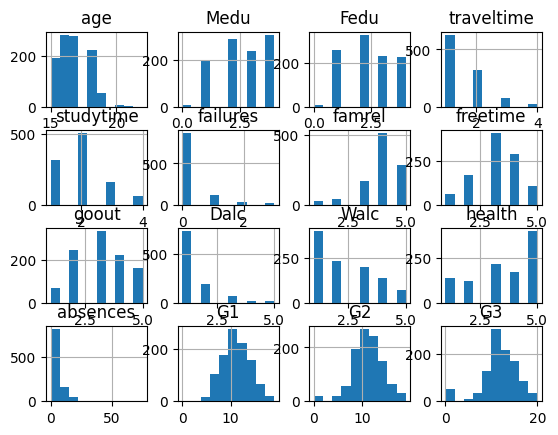

In [336]:
merged.hist()
plt.show()

Les colonnes G1, G2, et G3 semblent suivre une loi normale.

Nous devrions faire atention à la présence de valeurs aberrantes dans leurs distributions.

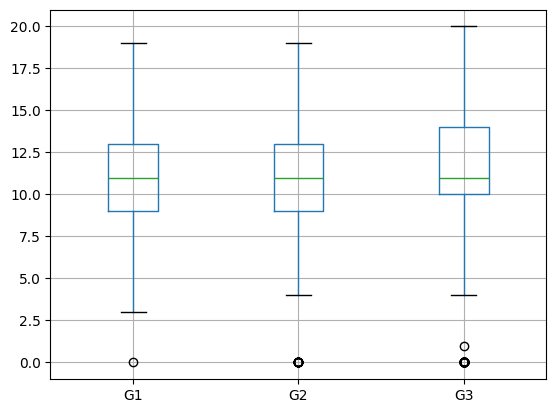

In [337]:
ax = merged.boxplot(column=["G1", "G2", "G3"])
ax.set_xticks(ax.get_xticks())  # Ensure rotation is applied to all ticks
ax.set_xticklabels(ax.get_xticklabels())
plt.show()

Nous retrouvons assez peu de valeurs aberrantes dans les notes, si ce n'est quelques 0.

Il vaudrait de toute façon mieux retirer les 0. Il est assez invraisemblable qu'un élève puisse obtenir une moyenne de 0/20. Il s'agit sûrement d'une erreur de saisie qu'il conviendrait de corriger.

## 5.MODÉLISATION

In [338]:
categorical_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus', 
    'Mjob', 'Fjob', 'reason', 'guardian', 
    'schoolsup', 'famsup', 'paid', 'activities', 
    'nursery', 'higher', 'internet', 'romantic', 'source'
]

def create_and_evaluate_regression(df):
    df_clone = df.copy()

    existing_cat_cols = [col for col in categorical_cols if col in df_clone.columns]
    ready = pd.get_dummies(df_clone, columns=existing_cat_cols, drop_first=True)

    X = ready.drop('G3', axis=1) # On enlève la cible des features
    y = ready['G3']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)

    y_pred = model.predict(X_test)

    r2_eval = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    actual_pass = y_test >= 10
    pred_pass = y_pred >= 10
    
    pass_fail_accuracy = np.mean(actual_pass == pred_pass)

    print("R2 train:", r2_train)
    print("R2 test:", r2_eval)
    print("RMSE:", rmse)
    print(f"Taux de bonnes classifications (Seuil 10/20) : {pass_fail_accuracy:.2%}")
    return model, r2_eval, rmse, pass_fail_accuracy


In [339]:
def create_and_evaluate_classification(df):
    df_clone = df.copy()

    df_clone['Pass'] = df_clone['G3'].apply(lambda x: 1 if x >= 10 else 0)

    existing_cat_cols = [col for col in categorical_cols if col in df_clone.columns]

    ready = pd.get_dummies(df_clone, columns=existing_cat_cols, drop_first=True)

    X = ready.drop(['G3', 'Pass'], axis=1)
    X = pd.get_dummies(X, drop_first=True)
    y = ready['Pass']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    classifier = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
    classifier.fit(X_train, y_train)

    plt.figure(figsize=(20, 10))  # On définit une grande taille d'image
    plot_tree(classifier, 
            feature_names=X.columns,  
            class_names=['Échec', 'Réussite'], # 0 et 1
            filled=True,              # Colore les noeuds selon la classe majoritaire
            rounded=True,             # Arrondit les bords des boîtes
            fontsize=10)

    plt.title("Arbre de Décision")
    plt.show()

    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Précision (Accuracy) : {accuracy:.2f}")

    return classifier, accuracy

## Scénario 1 – Toutes les variables disponibles

### Nettoyage des données

Nous devons supprimer les valeurs aberrantes des colonnes G1, G2 et G3.

Étant donné qu'il n'y a pas de valeurs manquantes, nous n'aurons pas à définir un protocole de remplacement cette fois-ci.

In [340]:
cleaned = merged.copy()

cleaned = cleaned.drop_duplicates()

threshold = 1.5

def find_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    outliers = cleaned[(col < Q1 - threshold * IQR) | (col > Q3 + threshold * IQR)]
    return outliers

g1_outliers = find_outliers(cleaned["G1"])
cleaned = cleaned.drop(g1_outliers.index)

g2_outliers = find_outliers(cleaned["G2"])
cleaned = cleaned.drop(g2_outliers.index)

g3_outliers = find_outliers(cleaned["G3"])
cleaned = cleaned.drop(g3_outliers.index)

cleaned.to_csv("./data/cleaned.csv", index=False)

cleaned.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,16.690928,2.627637,2.406118,1.514768,1.979958,0.226793,3.945148,3.200422,3.141350,1.498945,2.285865,3.550633,4.699367,11.415612,11.617089,11.957806
std,1.237585,1.127348,1.096526,0.721369,0.833954,0.606407,0.920922,1.037787,1.132723,0.924270,1.281635,1.426321,6.342172,2.875129,2.830667,2.896729
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,10.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,3.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Entraînement et évaluation du modèle de régression

In [341]:
print("Régression linéaire - Toutes les données")
regression_1, r2_1, rmse_1, pf_accuracy_1 = create_and_evaluate_regression(cleaned)

Régression linéaire - Toutes les données
R2 train: 0.9261057847730374
R2 test: 0.8855829383261606
RMSE: 0.9097443082047972
Taux de bonnes classifications (Seuil 10/20) : 87.37%


### Entraînement du modèle de classification

Classification - Toutes les données


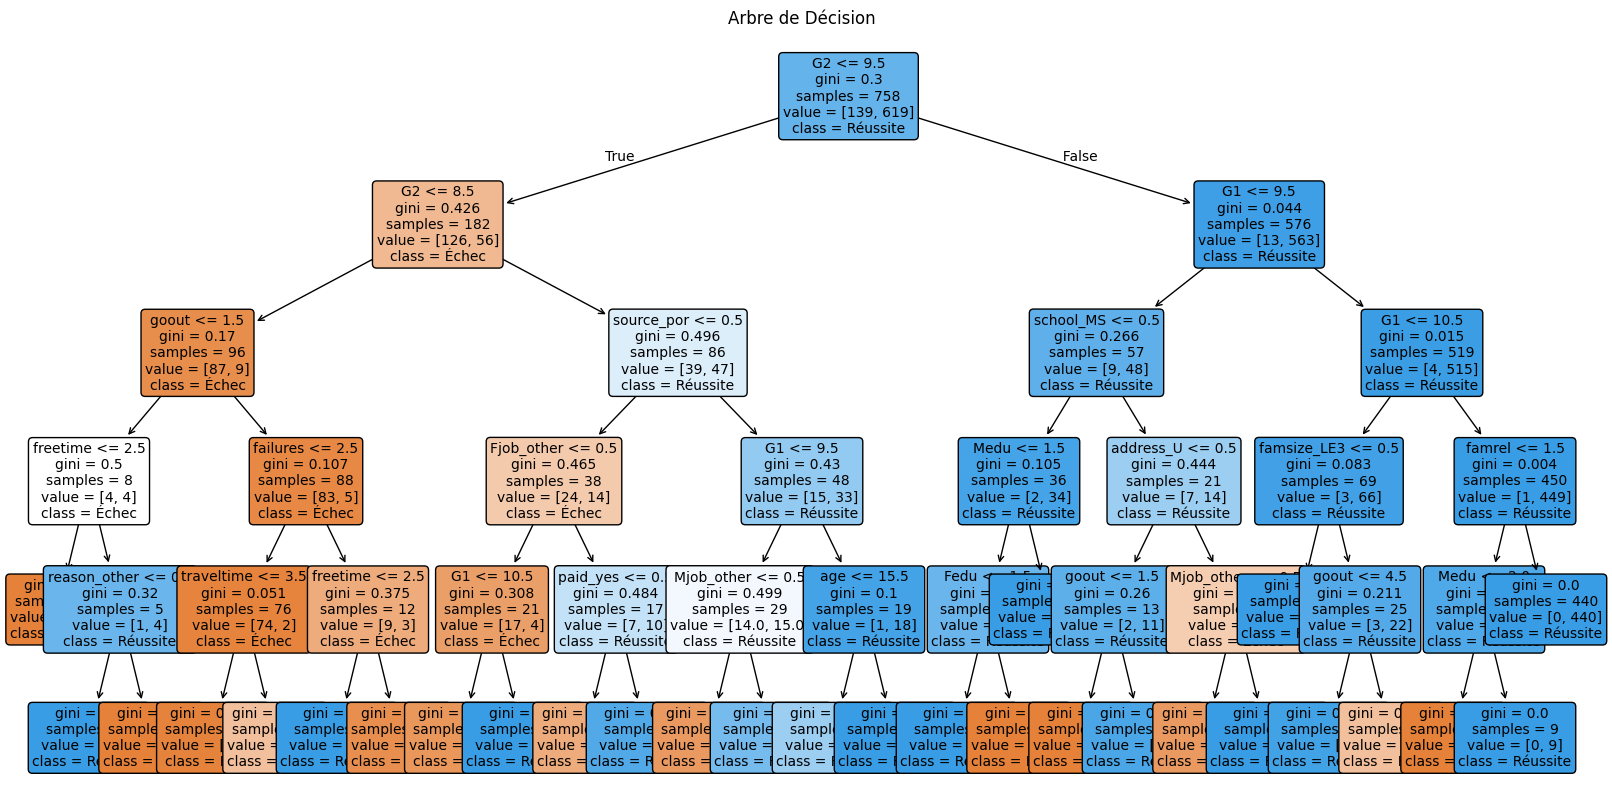

Précision (Accuracy) : 0.89


In [342]:
print("Classification - Toutes les données")
classification_1, accuracy_1 = create_and_evaluate_classification(cleaned)

## Scénario 2 – Sans variables sensibles

### Mise en conformité du jeu de données

Nous avons identifié certaines variables dans le jeu de données qui pourraient introduire des comportements discriminatoires :

- `sex` : Risque de discrimination directe. Un élève pourrait être favorisé ou pénalisé uniquement à cause de son genre.
- `age` : Un élève plus âgé (ayant redoublé) pourrait être jugé "moins capable".
- `health` : Donnée sensible du point de vue du RGPD.
- `dalc` : Consommation d'alcool, donnée pouvant être considérée comme sensible du point de vue du RGPD.
- `walc` : Consommation d'alcool, donnée pouvant être considérée comme sensible du point de vue du RGPD.
- `romantic` : Donnée strictement personnelle — que l'établissement ne devrait même pas posséder en premier lieu — et sans lien apparent avec ce que l'on cherche à prédire.
- `famrel` : Qualité des relations familiales. Extrêmement subjectif et intrusif.
- `Pstatus` : Statut marital des parents. Information privée sur la vie des parents. 
- `Mjob` : Métier du père. Pourrait introduire des biais vis-à-vis du déterminisme social.
- `Fjob` : Métier de la mère. Pourrait introduire des biais vis-à-vis du déterminisme social.
- `address` : Aucun rapport apparent avec ce que l'on cherche à prédire.

In [343]:
cols_to_drop = [
    'sex', 'age', 'health', 'Dalc', 'Walc', 'romantic', 'famrel', 'Pstatus', 'Mjob', 'Fjob', 'address'
]

# On retire uniquement les colonnes présentes dans le df
existing_cols_to_drop = [c for c in cols_to_drop if c in cleaned.columns]
ethical = cleaned.drop(existing_cols_to_drop, axis=1)

ethical.to_csv('./data/ethical.csv', index=False)

ethical.describe()

,Medu,Fedu,traveltime,studytime,failures,freetime,goout,absences,G1,G2,G3
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,2.627637,2.406118,1.514768,1.979958,0.226793,3.200422,3.141350,4.699367,11.415612,11.617089,11.957806
std,1.127348,1.096526,0.721369,0.833954,0.606407,1.037787,1.132723,6.342172,2.875129,2.830667,2.896729
min,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,2.000000,2.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.000000,9.000000,10.000000,10.000000
50%,3.000000,2.000000,1.000000,2.000000,0.000000,3.000000,3.000000,3.000000,11.000000,11.000000,12.000000
75%,4.000000,3.000000,2.000000,2.000000,0.000000,4.000000,4.000000,6.000000,13.000000,13.000000,14.000000
max,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Entraînement et évaluation du modèle de régression

In [344]:
print("Régression linéaire - Données conformes")
regression_2, r2_2, rmse_2, pf_accuracy_2 = create_and_evaluate_regression(ethical)

Régression linéaire - Données conformes
R2 train: 0.9230145595679906
R2 test: 0.8898424924906314
RMSE: 0.8926495743347117
Taux de bonnes classifications (Seuil 10/20) : 86.32%


### Entraînement et évaluation du modèle de classification

Classification - Données conformes


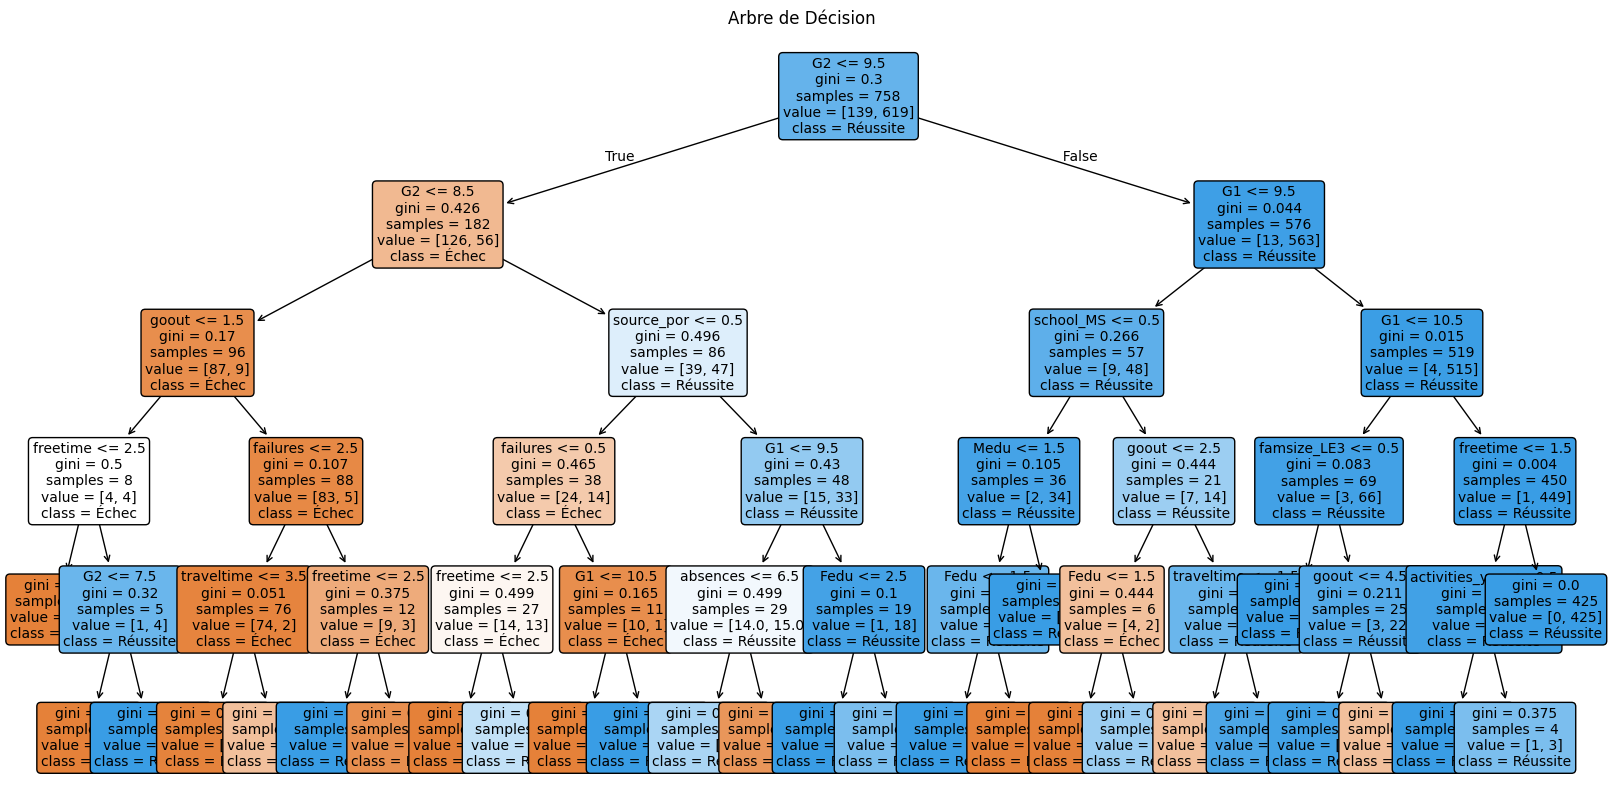

Précision (Accuracy) : 0.91


In [345]:
print("Classification - Données conformes")
classifier_2, accuracy_2 = create_and_evaluate_classification(ethical)

## Scénario 3 – Sans variables sensibles + sans G2

### Entraînement et évaluation du modèle de régression

In [346]:
ethical_no_g2 = ethical.drop('G2', axis=1, inplace=False)

print("Régression linéaire - Données conformes sans G2")
regression_3, r2_3, rmse_3, pf_accuracy_3 = create_and_evaluate_regression(ethical_no_g2)

Régression linéaire - Données conformes sans G2
R2 train: 0.8095616871477251
R2 test: 0.7668963845330866
RMSE: 1.2985194424699869
Taux de bonnes classifications (Seuil 10/20) : 87.89%


### Entraînement et évaluation du modèle de classification

Classification - Données conformes sans G2


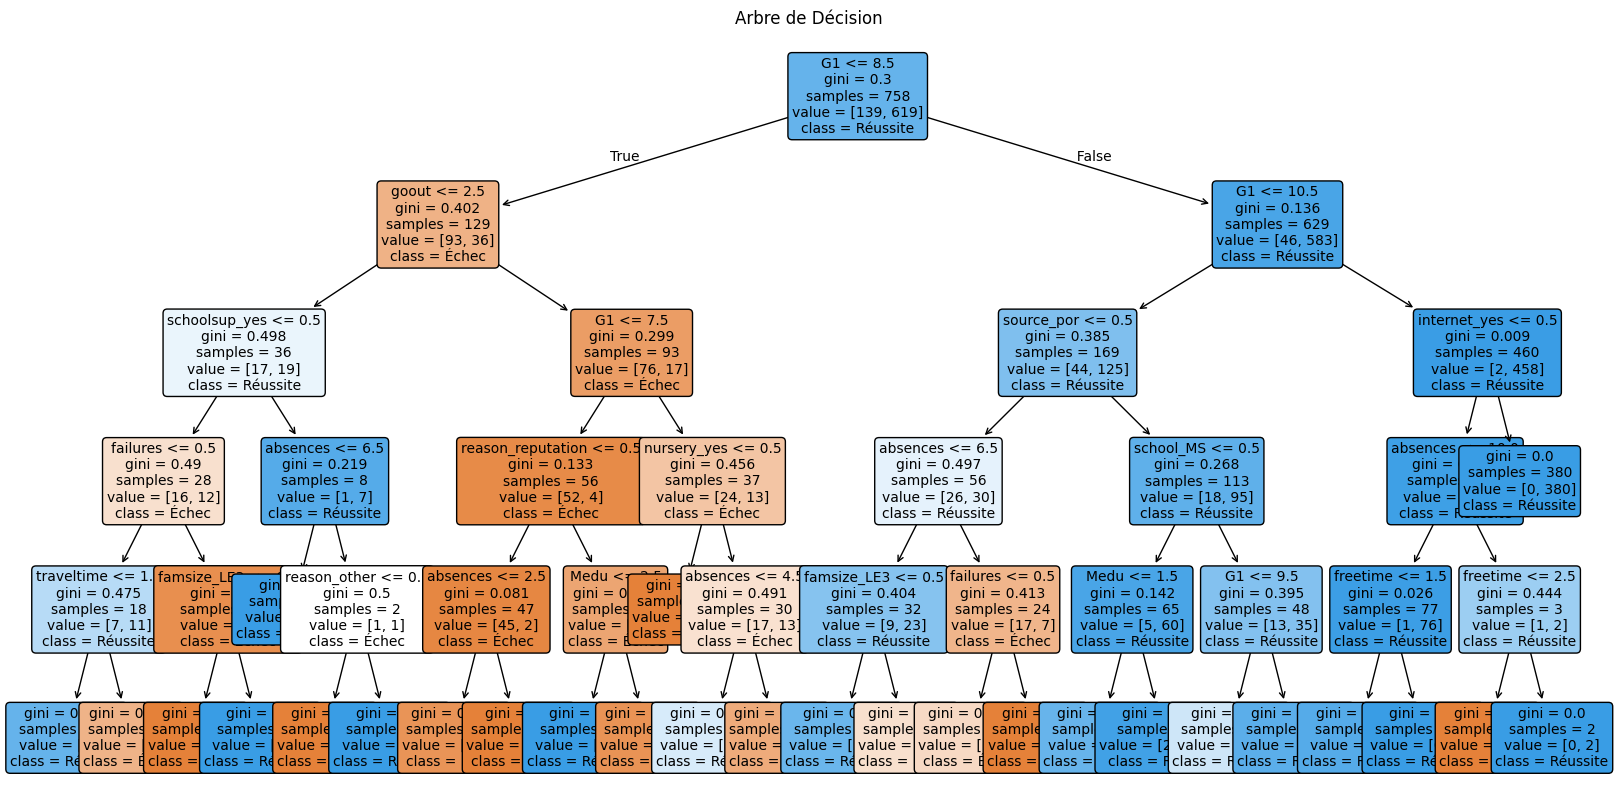

Précision (Accuracy) : 0.87


In [347]:
print("Classification - Données conformes sans G2")
classifier_3, accuracy_3 = create_and_evaluate_classification(ethical_no_g2)

## Scénario 4 – Sans variables sensibles + sans G1 et G2

### Entraînement et évaluation du modèle

In [348]:
ethical_no_g2_g1 = ethical.drop(['G2', 'G1'], axis=1, inplace=False)

print("Régression linéaire - Données conformes sans G2 ni G1")
regression_4, r2_4, rmse_4, pf_accuracy_4 = create_and_evaluate_regression(ethical_no_g2_g1)

Régression linéaire - Données conformes sans G2 ni G1
R2 train: 0.29777881443940546
R2 test: 0.25998942391262714
RMSE: 2.313624716221332
Taux de bonnes classifications (Seuil 10/20) : 80.53%


### Entraînement et évaluation du modèle de classification

Classification - Données conformes sans G2 ni G1


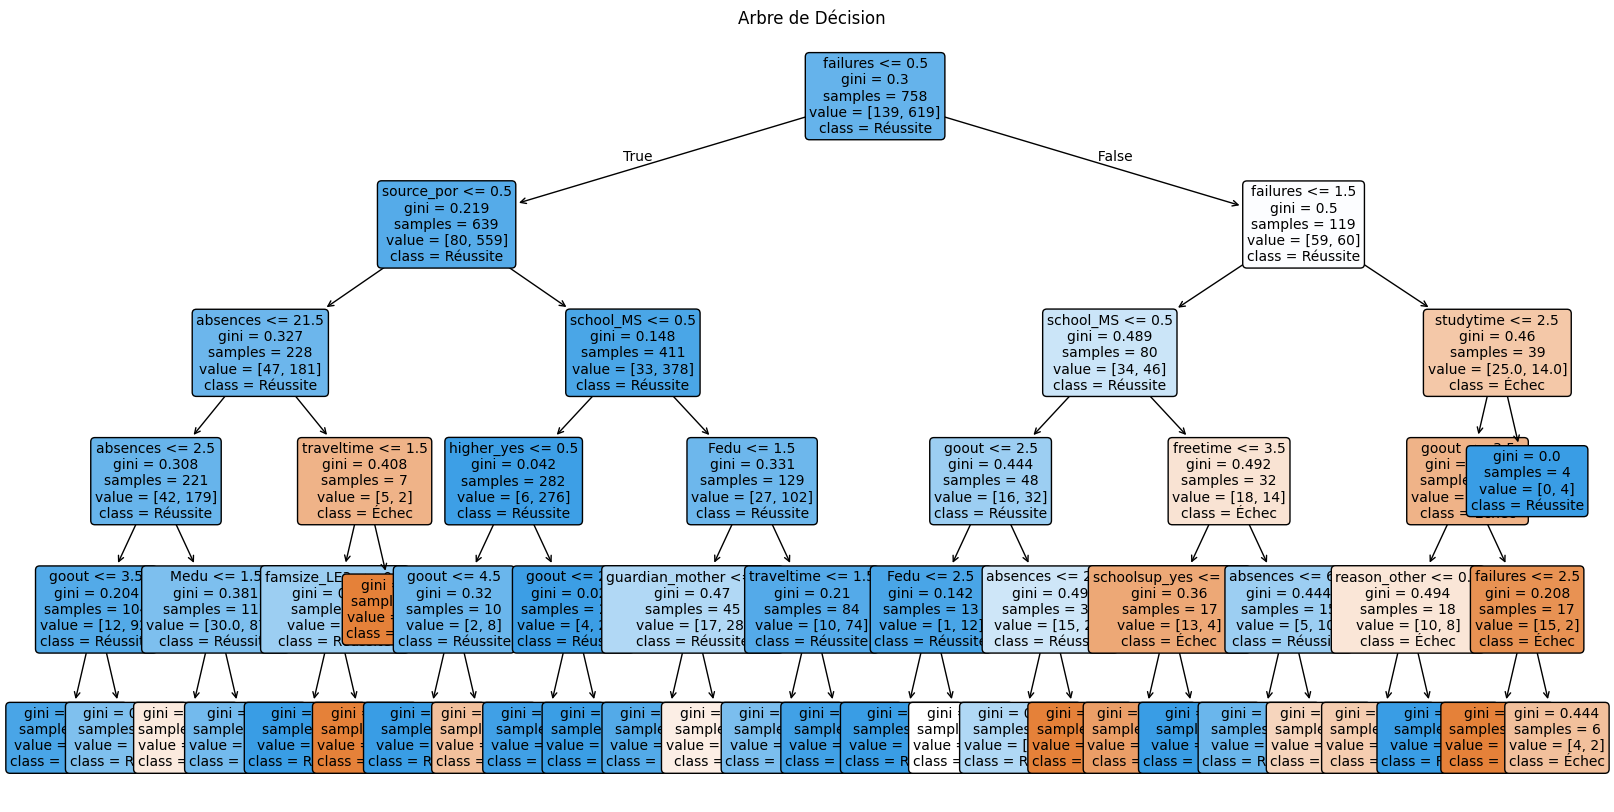

Précision (Accuracy) : 0.74


In [349]:
print("Classification - Données conformes sans G2 ni G1")
classifier_4, accuracy_4 = create_and_evaluate_classification(ethical_no_g2_g1)

## Conclusion

### Comparatif

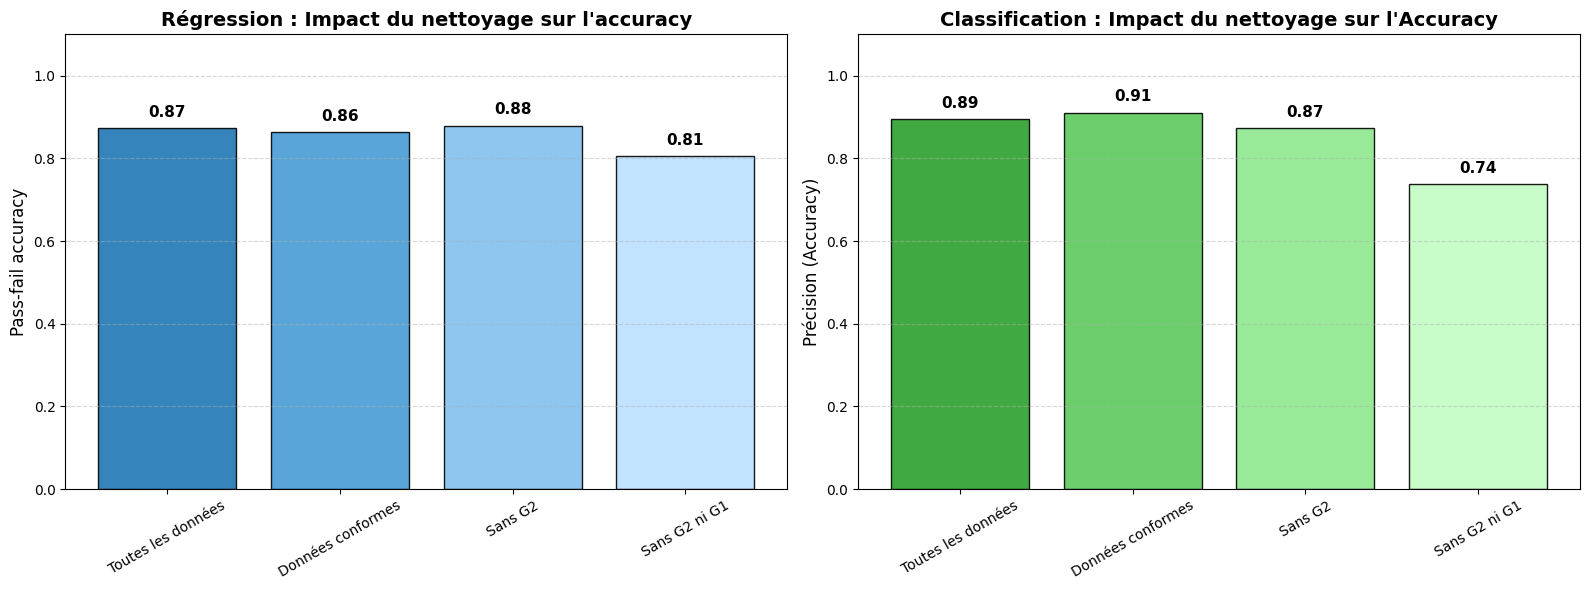

In [350]:
import matplotlib.pyplot as plt
import numpy as np

# --- 2. Définition des scénarios (La nouvelle dimension) ---
models = ['Toutes les données', 'Données conformes', 'Sans G2', 'Sans G2 ni G1']
pf_scores = [pf_accuracy_1, pf_accuracy_2, pf_accuracy_3, pf_accuracy_4]
acc_scores = [accuracy_1, accuracy_2, accuracy_3, accuracy_4]

# --- 3. Création du graphique ---
# figsize=(16, 6) : J'ai élargi un peu l'image pour accommoder les textes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique de Gauche : RÉGRESSION (R2) ---
# J'utilise une palette de bleus pour montrer la gradation
colors_r2 = ['#1f77b4', '#479bd5', '#82c0ef', '#bce0ff'] 
bars1 = ax1.bar(models, pf_scores, color=colors_r2, edgecolor='black', alpha=0.9)

ax1.set_title('Régression : Impact du nettoyage sur l\'accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Pass-fail accuracy', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Rotation des labels pour qu'ils ne se chevauchent pas
ax1.tick_params(axis='x', rotation=30)

# Ajout des valeurs
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Graphique de Droite : CLASSIFICATION (Accuracy) ---
# Palette de verts
colors_acc = ['#2ca02c', '#5bc95b', '#8de88d', '#c2fcc2']
bars2 = ax2.bar(models, acc_scores, color=colors_acc, edgecolor='black', alpha=0.9)

ax2.set_title('Classification : Impact du nettoyage sur l\'Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylabel('Précision (Accuracy)', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Rotation des labels
ax2.tick_params(axis='x', rotation=30)

# Ajout des valeurs
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Affichage final ---
plt.tight_layout() # Crucial pour que les labels rotatés ne soient pas coupés
plt.savefig('comparison_models.png')

### Quel modèle choisir ?

Nous ne pouvons bien sûr pas utiliser les modèles du scénario 1 car leurs données d'entraînement ne sont pas conforme au RGPD, et nous pouvons égaalement constater qu'ils ne sont pas forcément les plus performants.

Sur la simple tâche d'identifier la réussiste scolaire d'un élève, le meilleur modèle utilisable semble être le deuxième modèle de classification, qui a un taux de réussite de 91%.

C'est celui-là que nous devrons utiliser.

## Sauvegarde du modèle

In [351]:
joblib.dump(regression_4, './models/regression.joblib')

existing_cat_cols = [col for col in categorical_cols if col in ethical_no_g2_g1.columns]

print('Inputs:', pd.get_dummies(ethical_no_g2_g1, columns=existing_cat_cols, drop_first=True).drop(columns="G3").columns.values)

Inputs: ['Medu' 'Fedu' 'traveltime' 'studytime' 'failures' 'freetime' 'goout'
 'absences' 'school_MS' 'famsize_LE3' 'reason_home' 'reason_other'
 'reason_reputation' 'guardian_mother' 'guardian_other' 'schoolsup_yes'
 'famsup_yes' 'paid_yes' 'activities_yes' 'nursery_yes' 'higher_yes'
 'internet_yes' 'source_por']
